# Glovo AI Challenge: ETA Prediction & Optimization

MUDAB | Grupo 1

Cèlia García, Vinyet Delgado y Micaela Beti

## Índice

1. **Objetivo del proyecto**

2. **Carga y exploración de datos (EDA)**
    - Estructura general del dataset
    - Validación de timestamps
    - Distribución del tiempo total (ETA)
    - Detección de outliers en el ETA
    - Correlación de variables numéricas relevantes
    - Análisis de correlación

3. **Preprocesamiento de datos**
    - Definición de la variable objetivo
    - Distribución del tiempo de entrega
    - Selección inicial de variables

4. **Feature Engineering**
    - Cálculo de la distancia geográfica
    - Distribución de la distancia
    - Creación de variables temporales
    - Tratamiento de variables categóricas
    - Selección final de variables
    - Dataset final para modelado

5. **Modelado**
   - Split train / validation / test
   - Selección de modelos
   - Entrenamiento y comparativa
   - Corrección de data leakage
   - Optimización de hiperparámetros (XGBoost)
   - Validación cruzada (Cross-Validation)

6. **Análisis de resultados**
   - Comparativa visual de modelos
   - Predicho vs Real
   - Distribución de errores
   - Importancia de variables
   - Análisis de errores por segmento

7. **Mejoras del modelo**
   - Intervalos de predicción
   - Detección de pedidos tardíos
   - Análisis de coste asimétrico

8. **Conclusiones y recomendaciones de negocio**
   - Resumen del proyecto
   - Insights clave
   - Limitaciones del modelo
   - Recomendaciones de negocio

## 1. Objetivo del proyecto

El objetivo de este proyecto es desarrollar un modelo capaz de predecir el **Estimated Time of Arrival (ETA)** de los pedidos en Glovo, optimizando no solo la precisión de la predicción, sino también su impacto en métricas clave de negocio como:

- Conversión
- Experiencia de usuario (CX)
- Costes operativos

Además, se explorarán estrategias para:
- Gestionar la incertidumbre en las predicciones
- Detectar pedidos potencialmente tardíos
- Minimizar el impacto de errores en el ETA

## 2. Carga y exploración inicial de datos

En esta sección cargamos el dataset y realizamos una primera exploración para:

- Entender la estructura de los datos
- Identificar variables disponibles
- Detectar posibles problemas de calidad

In [ ]:
# Importar librerías
import pandas as pd

# Cargar dataset
df = pd.read_csv('glovo_ops_data_final.csv')

# Ver primeras filas
df.head()

,order_id,customer_id,courier_id,store_address_id,store_name,vertical,gtv,delivery_fee,description,activation_time_local,...,pickup_time_local,delivery_time_local,tranport_type,rating,bad_rating_reason,pickup_latitude,pickup_longitude,delivery_latitude,delivery_longitude,saturation
0,32.0,700734,441.0,10887.0,Pharmacie,WALL - Partner,19.97,4.9,1 x DOLIPRANE 1000mg - 8 comprimés\n1 x IMODIU...,2019-10-01 09:21:34.000,...,2019-10-01 09:34:55.904,2019-10-01 09:50:02.000,MOTORBIKE,5.0,NaN,48.861046,2.275441,48.855068,2.283378,66
1,29.0,1648235,239.0,3705.0,Starbucks,WALL - NonPartner,10.50,4.9,"1 x Caffe Latte - Tall, Espresso Roast Class...",2019-10-01 09:18:30.000,...,2019-10-01 09:36:02.133,2019-10-01 09:47:39.000,BICYCLE,NaN,NaN,48.871578,2.304495,48.867017,2.292787,40
2,292.0,13527080,351.0,1035.0,Starbucks,WALL - NonPartner,10.35,4.9,Venti Latte Vanille Glace avec seulement 2 pom...,2019-10-01 15:04:50.000,...,2019-10-01 15:25:37.131,2019-10-01 15:34:52.000,MOTORBIKE,5.0,NaN,48.855461,2.360776,48.866713,2.364773,29
3,743.0,275173,391.0,NaN,NaN,COURIER,6.60,6.6,Lunettes,2019-10-02 10:08:38.000,...,2019-10-02 10:30:24.559,2019-10-02 10:50:13.000,MOTORBIKE,NaN,NaN,48.859665,2.285694,48.884335,2.259989,54
4,838.0,1105241,263.0,51106.0,Franprix,WALL - Partner,13.10,3.9,"1 x Emmental rape 29% - Franprix - 3x35g - 1,4...",2019-10-02 12:12:09.000,...,2019-10-02 12:31:21.010,2019-10-02 12:38:04.000,MOTORBIKE,5.0,NaN,48.863417,2.361240,48.868087,2.371050,77


In [ ]:
# Información general del dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 63646 entries, 0 to 63645
Data columns (total 21 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   order_id                     63646 non-null  float64
 1   customer_id                  63646 non-null  int64  
 2   courier_id                   63646 non-null  float64
 3   store_address_id             52018 non-null  float64
 4   store_name                   52018 non-null  object 
 5   vertical                     63646 non-null  object 
 6   gtv                          63646 non-null  float64
 7   delivery_fee                 63646 non-null  float64
 8   description                  63614 non-null  object 
 9   activation_time_local        63646 non-null  object 
 10  courier_started_order_local  63642 non-null  object 
 11  pickup_time_local            63646 non-null  object 
 12  delivery_time_local          63646 non-null  object 
 13  tranport_type   

In [ ]:
# Estadísticas básicas
df.describe()

,order_id,customer_id,courier_id,store_address_id,gtv,delivery_fee,rating,pickup_latitude,pickup_longitude,delivery_latitude,delivery_longitude,saturation
count,63646.000000,6.364600e+04,63646.000000,52018.000000,63646.000000,63646.000000,26784.000000,63646.000000,63646.000000,63646.000000,63646.000000,63646.000000
mean,42599.441033,7.339444e+06,281.304183,42794.678477,23.475663,5.569971,4.820154,48.864058,2.321907,48.864130,2.318299,77.772633
std,24605.798877,8.219375e+06,140.223522,41522.426586,17.365952,3.661555,0.827880,0.017255,0.037469,0.020156,0.040682,36.107480
min,1.000000,1.154000e+03,1.000000,911.000000,0.000000,0.000000,1.000000,48.803918,2.221335,48.794007,2.211807,20.000000
25%,21298.250000,1.094467e+06,165.000000,7113.000000,12.900000,3.900000,5.000000,48.852065,2.289582,48.850450,2.287040,51.000000
50%,42649.500000,3.209173e+06,303.000000,23886.000000,18.390000,3.900000,5.000000,48.866397,2.322111,48.865338,2.314835,73.000000
75%,63922.750000,1.167532e+07,403.000000,78604.000000,28.500000,6.900000,5.000000,48.876436,2.349763,48.878739,2.348273,98.000000
max,85126.000000,2.986686e+07,534.000000,136345.000000,346.620000,23.900000,5.000000,48.916104,2.437825,48.928184,2.443143,239.000000


In [ ]:
# Valores nulos
df.isnull().sum().sort_values(ascending=False)

,0
bad_rating_reason,61133
rating,36862
store_name,11628
store_address_id,11628
description,32
courier_started_order_local,4
customer_id,0
order_id,0
courier_id,0
delivery_fee,0


### Estructura general del dataset

- El dataset contiene **63,646 observaciones** y **21 variables**
- Incluye información de:
  - Pedidos (`order_id`)
  - Usuarios, couriers y tiendas
  - Tiempos del proceso logístico
  - Coordenadas geográficas
  - Variables operativas como `saturation`

El dataset es suficientemente grande y rico para construir un modelo predictivo robusto.

---

### Variables temporales (CRÍTICAS)

- Las variables de tiempo (`activation`, `courier_started`, `pickup`, `delivery`) están en formato **string**
- Será necesario:
  - Convertirlas a formato datetime
  - Validar su consistencia (orden lógico)
  - Transformarlas en diferencias de tiempo (minutos)

Estas variables serán la base para construir el **target (ETA)** y features clave.

---

### Valores nulos

Se observan varios problemas relevantes:

- `bad_rating_reason`: ~61k valores nulos → prácticamente inutilizable
- `rating`: ~36k nulos → información incompleta
- `store_name` y `store_address_id`: ~11k nulos → importante revisar

Decisión preliminar:
- Eliminar variables de rating (no disponibles en tiempo real)
- Evaluar si imputar o eliminar registros con missing en tienda

### Validación de timestamps

Aseguramos que los timestamps siguen un orden lógico en el proceso:

1. activation_time_local → creación del pedido  
2. courier_started_order_local → asignación del courier  
3. pickup_time_local → recogida  
4. delivery_time_local → entrega  

Cualquier inconsistencia en este orden indica problemas de calidad de datos que deben ser tratados antes de modelar.

In [ ]:
# Convertir a datetime
date_cols = [
    'activation_time_local',
    'courier_started_order_local',
    'pickup_time_local',
    'delivery_time_local'
]

for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

In [ ]:
# Crear diferencias de tiempo en minutos
df['time_to_assign'] = (df['courier_started_order_local'] - df['activation_time_local']).dt.total_seconds() / 60

df['prep_time'] = (df['pickup_time_local'] - df['courier_started_order_local']).dt.total_seconds() / 60

df['delivery_time'] = (df['delivery_time_local'] - df['pickup_time_local']).dt.total_seconds() / 60

df['total_time'] = (df['delivery_time_local'] - df['activation_time_local']).dt.total_seconds() / 60

In [ ]:
# Crear flags individuales de inconsistencias
df['inc_time_to_assign'] = df['time_to_assign'] < 0
df['inc_prep_time'] = df['prep_time'] < 0
df['inc_delivery_time'] = df['delivery_time'] < 0
df['inc_total_time'] = df['total_time'] < 0

# Contar cada tipo
print("Inconsistencias time_to_assign:", df['inc_time_to_assign'].sum())
print("Inconsistencias prep_time:", df['inc_prep_time'].sum())
print("Inconsistencias delivery_time:", df['inc_delivery_time'].sum())
print("Inconsistencias total_time:", df['inc_total_time'].sum())

Inconsistencias time_to_assign: 16605
Inconsistencias prep_time: 399
Inconsistencias delivery_time: 126
Inconsistencias total_time: 0


In [ ]:
# Porcentaje de cada tipo
print("time_to_assign (%):", df['inc_time_to_assign'].mean() * 100)
print("prep_time (%):", df['inc_prep_time'].mean() * 100)
print("delivery_time (%):", df['inc_delivery_time'].mean() * 100)
print("total_time (%):", df['inc_total_time'].mean() * 100)

time_to_assign (%): 26.089620714577507
prep_time (%): 0.6269050686610314
delivery_time (%): 0.19797002168243094
total_time (%): 0.0


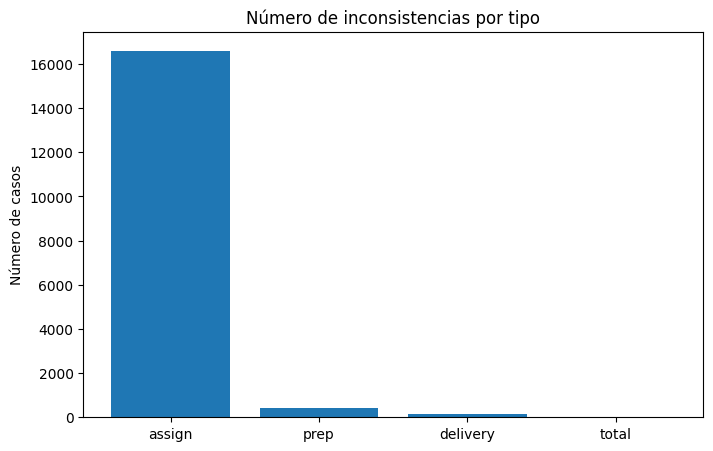

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualización de inconsistencias
inconsistencies = {
    'assign': df['inc_time_to_assign'].sum(),
    'prep': df['inc_prep_time'].sum(),
    'delivery': df['inc_delivery_time'].sum(),
    'total': df['inc_total_time'].sum()
}

plt.figure(figsize=(8,5))
plt.bar(inconsistencies.keys(), inconsistencies.values())
plt.title('Número de inconsistencias por tipo')
plt.ylabel('Número de casos')
plt.show()

**Conclusión**

Se observa que las inconsistencias temporales se concentran principalmente en la fase de asignación del courier (~26% de los casos), mientras que las etapas posteriores presentan un nivel de error muy bajo.

Esto sugiere que los problemas de calidad de datos están asociados al registro del evento de asignación, y no al proceso logístico en sí.

Dadas estas inconsistencias haremos una comparación entre ETA total oficial y ETA alternativo (donde nos quedaremos con el valor más antiguo de los campos `activation_time_local` y `courier_started_order_local`).

Para analizar el impacto de las inconsistencias temporales, vamos a comparar dos formas de calcular el ETA:

1. **ETA oficial**: tiempo entre `activation_time_local` y `delivery_time_local`
2. **ETA alternativo**: tiempo entre el timestamp más antiguo registrado y `delivery_time_local`

El objetivo no es cambiar directamente la variable objetivo, sino evaluar si las inconsistencias en timestamps intermedios tienen un impacto significativo sobre el cálculo del tiempo total.

In [ ]:
# Crear una columna con el timestamp más antiguo entre los principales eventos del pedido
df['first_timestamp'] = df[
    [
        'activation_time_local',
        'courier_started_order_local',
        'pickup_time_local'
    ]
].min(axis=1)

df[['activation_time_local', 'courier_started_order_local', 'pickup_time_local', 'first_timestamp']].head()

,activation_time_local,courier_started_order_local,pickup_time_local,first_timestamp
0,2019-10-01 09:21:34,2019-10-01 09:19:06.342,2019-10-01 09:34:55.904,2019-10-01 09:19:06.342
1,2019-10-01 09:18:30,2019-10-01 09:28:04.560,2019-10-01 09:36:02.133,2019-10-01 09:18:30.000
2,2019-10-01 15:04:50,2019-10-01 15:04:28.032,2019-10-01 15:25:37.131,2019-10-01 15:04:28.032
3,2019-10-02 10:08:38,2019-10-02 10:11:26.078,2019-10-02 10:30:24.559,2019-10-02 10:08:38.000
4,2019-10-02 12:12:09,2019-10-02 12:10:54.226,2019-10-02 12:31:21.010,2019-10-02 12:10:54.226


In [ ]:
# ETA oficial: desde activación hasta entrega
df['eta_activation'] = (
    df['delivery_time_local'] - df['activation_time_local']
).dt.total_seconds() / 60

# ETA alternativo: desde el primer timestamp registrado hasta entrega
df['eta_first_timestamp'] = (
    df['delivery_time_local'] - df['first_timestamp']
).dt.total_seconds() / 60

df[['eta_activation', 'eta_first_timestamp']].head()

,eta_activation,eta_first_timestamp
0,28.466667,30.927633
1,29.150000,29.150000
2,30.033333,30.399467
3,41.583333,41.583333
4,25.916667,27.162900


In [ ]:
# Diferencia entre ambos ETAs
df['eta_diff'] = df['eta_first_timestamp'] - df['eta_activation']
df['eta_diff_abs'] = df['eta_diff'].abs()

print("Diferencia media (min):", df['eta_diff_abs'].mean())

df['eta_diff_pct'] = df['eta_diff_abs'] / df['eta_activation'] * 100
print("Impacto medio (%):", df['eta_diff_pct'].mean())

(df['eta_diff_abs'] > 0).mean() * 100

Diferencia media (min): 0.4583734557814579
Impacto medio (%): 1.6406989332640916


np.float64(26.13518524337743)

**Conclusión del impacto de inconsistencias temporales**

Se comparó el cálculo del ETA utilizando:

- `activation_time_local` (enfoque estándar)
- el timestamp más temprano disponible (enfoque alternativo)

Resultados:

- Diferencia media: ~0.46 minutos
- Impacto relativo: ~1.6%
- % de pedidos afectados: ~26%

Aunque existe un porcentaje elevado de inconsistencias en los timestamps intermedios, su impacto sobre el ETA total es muy reducido.

Esto indica que el cálculo del ETA basado en `activation_time_local` es robusto y puede utilizarse de forma fiable como variable objetivo para el modelo.

### Distribución del tiempo total (ETA)

Se analiza la distribución del tiempo total de entrega (ETA) para:

- Entender la forma de la distribución
- Detectar posibles outliers
- Evaluar la variabilidad del proceso logístico

Esto es clave antes de entrenar cualquier modelo.

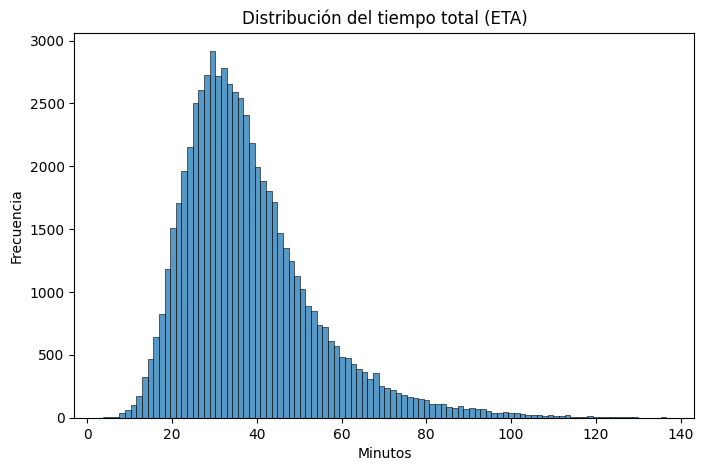

In [ ]:
# Distribución del tiempo total
plt.figure(figsize=(8,5))
sns.histplot(df['total_time'], bins=100)
plt.title('Distribución del tiempo total (ETA)')
plt.xlabel('Minutos')
plt.ylabel('Frecuencia')
plt.show()

### Detección de outliers en el ETA

Se analizan los valores extremos del tiempo de entrega para identificar pedidos atípicos que podrían afectar negativamente al modelo.

In [ ]:
# Percentiles clave
df['total_time'].describe(percentiles=[0.90, 0.95, 0.99])

,total_time
count,63646.000000
mean,38.127949
std,15.639348
min,3.633333
50%,35.100000
90%,58.250000
95%,68.266667
99%,91.360833
max,136.600000


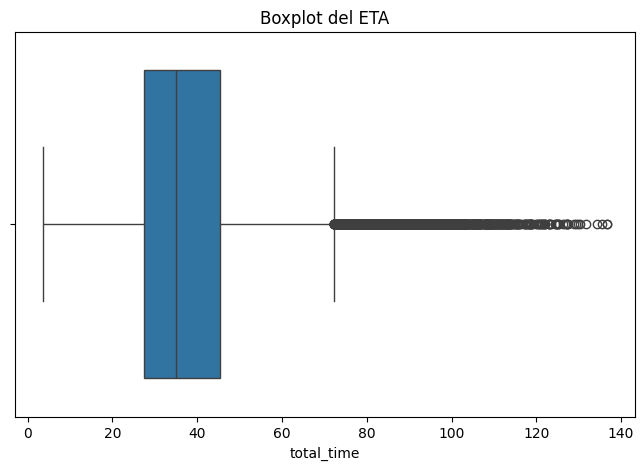

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['total_time'])
plt.title('Boxplot del ETA')
plt.show()

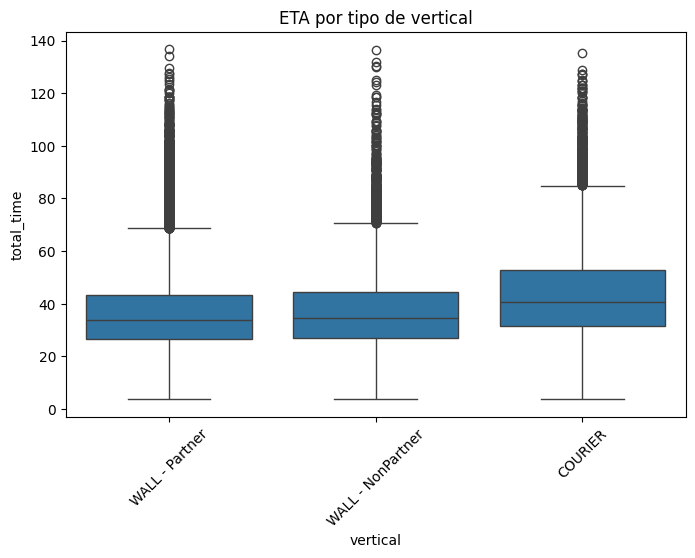

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x='vertical', y='total_time', data=df)
plt.title('ETA por tipo de vertical')
plt.xticks(rotation=45)
plt.show()

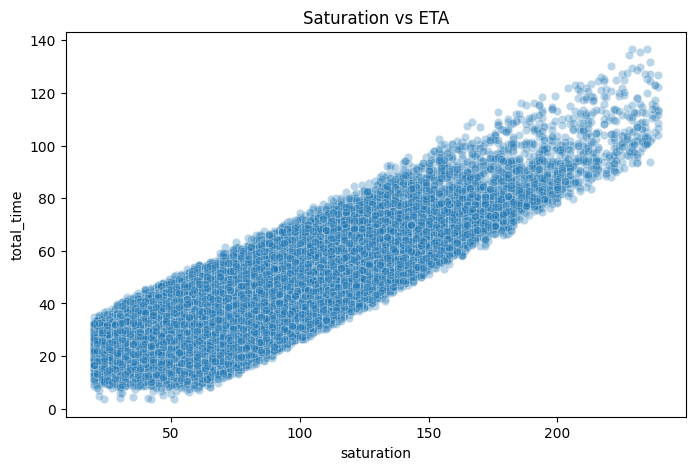

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='saturation', y='total_time', data=df, alpha=0.3)
plt.title('Saturation vs ETA')
plt.show()

### Correlación de variables numéricas relevantes

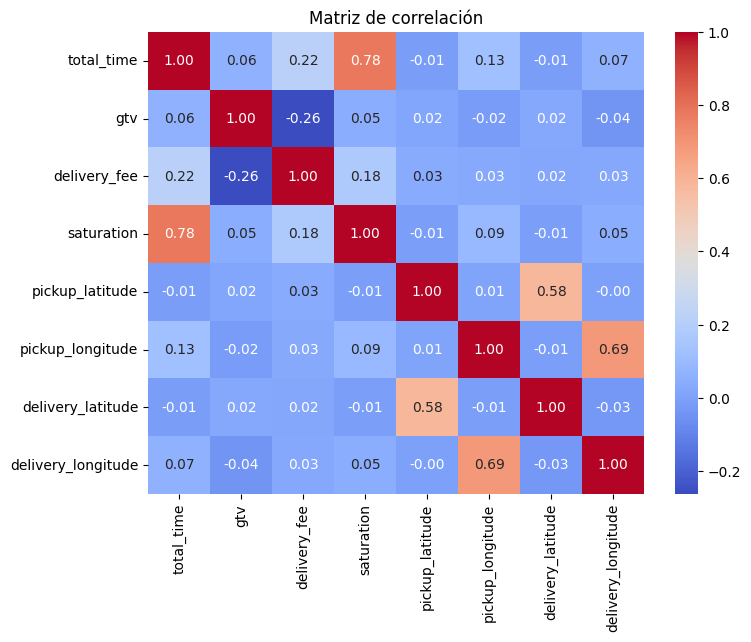

In [ ]:
# Selección de variables numéricas relevantes
num_cols = [
    'total_time',
    'gtv',
    'delivery_fee',
    'saturation',
    'pickup_latitude',
    'pickup_longitude',
    'delivery_latitude',
    'delivery_longitude'
]

corr = df[num_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title('Matriz de correlación')
plt.show()

### Análisis de correlación

La matriz de correlación muestra que la variable más fuertemente relacionada con el tiempo de entrega (`total_time`) es `saturation`, con una correlación positiva elevada (~0.78). Esto indica que el nivel de saturación del sistema es un factor clave en el incremento del ETA.

Por el contrario, variables como `gtv` y `delivery_fee` presentan correlaciones débiles, lo que sugiere que el valor económico del pedido tiene un impacto limitado en el tiempo de entrega.

Las coordenadas geográficas no muestran una relación directa con el ETA, aunque presentan correlaciones entre sí, lo cual es esperable. Esto sugiere que será más relevante trabajar con variables derivadas, como la distancia entre el punto de recogida y el de entrega.

En conjunto, la ausencia de múltiples correlaciones fuertes indica que el problema presenta una estructura compleja, donde diferentes factores interactúan de forma no lineal.

## 3. Preprocesamiento de datos

En esta sección se prepara el dataset para su uso en modelos predictivos.

Tras el análisis exploratorio, se procede a:

- Definir la variable objetivo (ETA)
- Limpiar posibles inconsistencias restantes
- Preparar las variables para el modelado

### Definición de la variable objetivo

Se define la variable objetivo `ETA` como el tiempo transcurrido entre la activación del pedido (`activation_time_local`) y su entrega (`delivery_time_local`).

Esta definición refleja el tiempo total percibido por el cliente y es consistente con el objetivo de negocio.

In [ ]:
# Crear variable objetivo final (ETA en minutos)
df['ETA'] = (
    df['delivery_time_local'] - df['activation_time_local']
).dt.total_seconds() / 60

# Comprobar resultados
df['ETA'].describe()

,ETA
count,63646.000000
mean,38.127949
std,15.639348
min,3.633333
25%,27.400000
50%,35.100000
75%,45.333333
max,136.600000


### Distribución del tiempo de entrega

La distribución del ETA presenta una forma asimétrica con una cola hacia la derecha, lo cual es habitual en variables de tiempo.

Se observan valores elevados que, aunque podrían considerarse atípicos desde un punto de vista estadístico, resultan coherentes con situaciones reales del sistema (por ejemplo, alta saturación o incidencias operativas).

Por este motivo, se decide mantener estos valores en el dataset, con el objetivo de preservar la variabilidad real del problema y mejorar la capacidad del modelo para generalizar en distintos escenarios.

ETAs negativos: 0


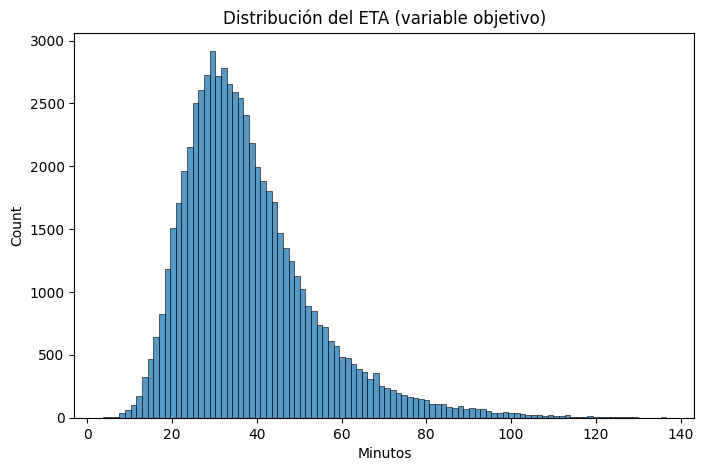

In [ ]:
# Ver valores negativos o raros
print("ETAs negativos:", (df['ETA'] < 0).sum())

# Visual rápida
plt.figure(figsize=(8,5))
sns.histplot(df['ETA'], bins=100)
plt.title('Distribución del ETA (variable objetivo)')
plt.xlabel('Minutos')
plt.show()

### Selección inicial de variables

Antes de crear nuevas variables, se realiza una primera selección de columnas.

Se eliminan aquellas variables que no se consideran útiles para el modelo o que podrían introducir problemas de fuga de información:

- Identificadores: `order_id`, `customer_id`, `courier_id`
- Variables posteriores a la entrega: `rating`, `bad_rating_reason`
- Texto libre: `description`

In [ ]:
# Copia del dataset para preprocesamiento
df_model = df.copy()

# Variables a eliminar en esta primera aproximación
cols_to_drop = [
    'order_id',
    'customer_id',
    'courier_id',
    'rating',
    'bad_rating_reason',
    'description'
]

df_model = df_model.drop(columns=cols_to_drop)

df_model.head()

,store_address_id,store_name,vertical,gtv,delivery_fee,activation_time_local,courier_started_order_local,pickup_time_local,delivery_time_local,tranport_type,...,inc_prep_time,inc_delivery_time,inc_total_time,first_timestamp,eta_activation,eta_first_timestamp,eta_diff,eta_diff_abs,eta_diff_pct,ETA
0,10887.0,Pharmacie,WALL - Partner,19.97,4.9,2019-10-01 09:21:34,2019-10-01 09:19:06.342,2019-10-01 09:34:55.904,2019-10-01 09:50:02,MOTORBIKE,...,False,False,False,2019-10-01 09:19:06.342,28.466667,30.927633,2.460967,2.460967,8.645082,28.466667
1,3705.0,Starbucks,WALL - NonPartner,10.50,4.9,2019-10-01 09:18:30,2019-10-01 09:28:04.560,2019-10-01 09:36:02.133,2019-10-01 09:47:39,BICYCLE,...,False,False,False,2019-10-01 09:18:30.000,29.150000,29.150000,0.000000,0.000000,0.000000,29.150000
2,1035.0,Starbucks,WALL - NonPartner,10.35,4.9,2019-10-01 15:04:50,2019-10-01 15:04:28.032,2019-10-01 15:25:37.131,2019-10-01 15:34:52,MOTORBIKE,...,False,False,False,2019-10-01 15:04:28.032,30.033333,30.399467,0.366133,0.366133,1.219090,30.033333
3,NaN,NaN,COURIER,6.60,6.6,2019-10-02 10:08:38,2019-10-02 10:11:26.078,2019-10-02 10:30:24.559,2019-10-02 10:50:13,MOTORBIKE,...,False,False,False,2019-10-02 10:08:38.000,41.583333,41.583333,0.000000,0.000000,0.000000,41.583333
4,51106.0,Franprix,WALL - Partner,13.10,3.9,2019-10-02 12:12:09,2019-10-02 12:10:54.226,2019-10-02 12:31:21.010,2019-10-02 12:38:04,MOTORBIKE,...,False,False,False,2019-10-02 12:10:54.226,25.916667,27.162900,1.246233,1.246233,4.808617,25.916667


## 4. Feature Engineering

### Cálculo de la distancia geográfica

Las coordenadas geográficas (latitud y longitud) no son directamente interpretables por un modelo.

Por ello, se calcula la distancia entre el punto de recogida (`pickup`) y el punto de entrega (`delivery`) utilizando la fórmula de Haversine, que permite estimar la distancia entre dos puntos en la superficie terrestre.

Esta variable será una de las principales explicativas del tiempo de entrega.

In [ ]:
import numpy as np

def haversine(lat1, lon1, lat2, lon2):
    # Convertir a radianes
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])

    # Diferencias
    dlat = lat2 - lat1
    dlon = lon2 - lon1

    # Fórmula
    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    c = 2 * np.arcsin(np.sqrt(a))

    # Radio de la Tierra en km
    r = 6371

    return c * r

In [ ]:
# Crear variable distancia en df_model
df_model['distance_km'] = haversine(
    df_model['pickup_latitude'],
    df_model['pickup_longitude'],
    df_model['delivery_latitude'],
    df_model['delivery_longitude']
)

df_model['distance_km'].describe()

,distance_km
count,63646.000000
mean,2.461211
std,1.686053
min,0.006302
25%,1.241154
50%,2.092532
75%,3.257730
max,14.179735


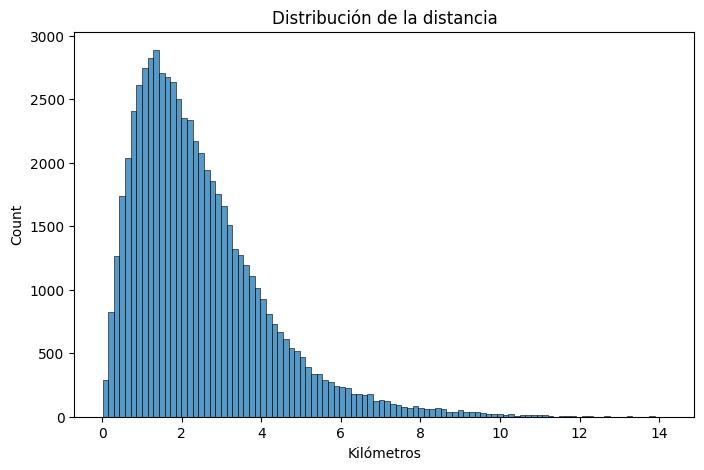

In [ ]:
# Validación
plt.figure(figsize=(8,5))
sns.histplot(df_model['distance_km'], bins=100)
plt.title('Distribución de la distancia')
plt.xlabel('Kilómetros')
plt.show()

### Distribución de la distancia

La distribución de la distancia presenta una clara asimetría hacia la derecha, concentrándose la mayoría de los pedidos en distancias cortas.

Esto es consistente con el modelo operativo del servicio, donde las entregas suelen realizarse en áreas geográficas próximas. No obstante, se observa la presencia de pedidos de mayor distancia, que podrían estar asociados a tiempos de entrega más elevados.

### Creación de variables temporales

El tiempo de entrega puede variar en función del momento en el que se realiza el pedido.

Por este motivo, se generan variables temporales a partir de `activation_time_local`:

- **Hora del pedido (`order_hour`)**: variable numérica que captura la hora exacta del día.
- **Franja horaria (`time_slot`)**: agrupación de la hora en categorías (mañana, mediodía, tarde y noche).
- **Indicador de fin de semana (`is_weekend`)**: variable binaria que distingue entre días laborables y fines de semana.

In [ ]:
# Hora del día
df_model['order_hour'] = df_model['activation_time_local'].dt.hour

# Crear franjas horarias
def get_time_slot(hour):
    if 6 <= hour < 12:
        return 'morning'
    elif 12 <= hour < 16:
        return 'midday'
    elif 16 <= hour < 21:
        return 'afternoon'
    else:
        return 'night'

df_model['time_slot'] = df_model['order_hour'].apply(get_time_slot)

df_model[['order_hour', 'time_slot']].head()

,order_hour,time_slot
0,9,morning
1,9,morning
2,15,midday
3,10,morning
4,12,midday


In [ ]:
# Crear indicador: 0 = día laborable, 1 = fin de semana
df_model['is_weekend'] = df_model['activation_time_local'].dt.dayofweek.isin([5, 6]).astype(int)

df_model[['activation_time_local', 'is_weekend']].head()

,activation_time_local,is_weekend
0,2019-10-01 09:21:34,0
1,2019-10-01 09:18:30,0
2,2019-10-01 15:04:50,0
3,2019-10-02 10:08:38,0
4,2019-10-02 12:12:09,0


### Tratamiento de variables categóricas

Algunas variables del dataset son de tipo categórico y no pueden ser utilizadas directamente por los modelos.

Por este motivo, se transforman mediante one-hot encoding, permitiendo convertirlas en variables numéricas.

Se aplica one-hot encoding a: `store_name`, `vertical`, `tranport_type`, `time_slot`.

In [ ]:
# Variables categóricas
categorical_cols = [
    'store_name',
    'vertical',
    'tranport_type',
    'time_slot'
]

# One-hot encoding
df_model = pd.get_dummies(
    df_model,
    columns=categorical_cols,
    drop_first=True
)

df_model.head()

,store_address_id,gtv,delivery_fee,activation_time_local,courier_started_order_local,pickup_time_local,delivery_time_local,pickup_latitude,pickup_longitude,delivery_latitude,...,store_name_Ô Saigon,store_name_Ô lieu de,vertical_WALL - NonPartner,vertical_WALL - Partner,tranport_type_CAR,tranport_type_MOTORBIKE,tranport_type_WALKER,time_slot_midday,time_slot_morning,time_slot_night
0,10887.0,19.97,4.9,2019-10-01 09:21:34,2019-10-01 09:19:06.342,2019-10-01 09:34:55.904,2019-10-01 09:50:02,48.861046,2.275441,48.855068,...,False,False,False,True,False,True,False,False,True,False
1,3705.0,10.50,4.9,2019-10-01 09:18:30,2019-10-01 09:28:04.560,2019-10-01 09:36:02.133,2019-10-01 09:47:39,48.871578,2.304495,48.867017,...,False,False,True,False,False,False,False,False,True,False
2,1035.0,10.35,4.9,2019-10-01 15:04:50,2019-10-01 15:04:28.032,2019-10-01 15:25:37.131,2019-10-01 15:34:52,48.855461,2.360776,48.866713,...,False,False,True,False,False,True,False,True,False,False
3,NaN,6.60,6.6,2019-10-02 10:08:38,2019-10-02 10:11:26.078,2019-10-02 10:30:24.559,2019-10-02 10:50:13,48.859665,2.285694,48.884335,...,False,False,False,False,False,True,False,False,True,False
4,51106.0,13.10,3.9,2019-10-02 12:12:09,2019-10-02 12:10:54.226,2019-10-02 12:31:21.010,2019-10-02 12:38:04,48.863417,2.361240,48.868087,...,False,False,False,True,False,True,False,True,False,False


### Selección final de variables

Una vez creadas las nuevas variables y transformadas las variables categóricas, se define el conjunto final de variables que se utilizarán para el entrenamiento del modelo.

Se eliminan aquellas columnas que no aportan valor predictivo o que no estarían disponibles en un escenario real de predicción.

In [ ]:
# Eliminación final de variables (evitar data leakage y columnas no necesarias)

cols_to_drop_final = [
    # Timestamps originales
    'activation_time_local',
    'courier_started_order_local',
    'pickup_time_local',
    'delivery_time_local',

    # Variables derivadas del target (data leakage)
    'total_time',
    'eta_activation',
    'eta_first_timestamp',
    'eta_diff',
    'eta_diff_abs',
    'eta_diff_pct',
    'first_timestamp',

    # Flags de inconsistencias
    'inc_time_to_assign',
    'inc_prep_time',
    'inc_delivery_time',
    'inc_total_time'
]

# Drop seguro (evita errores si alguna columna ya no existe)
df_model = df_model.drop(columns=cols_to_drop_final, errors='ignore')

# Comprobación final
print("Shape final:", df_model.shape)
df_model.head()

Shape final: (63646, 589)


,store_address_id,gtv,delivery_fee,pickup_latitude,pickup_longitude,delivery_latitude,delivery_longitude,saturation,time_to_assign,prep_time,...,store_name_Ô Saigon,store_name_Ô lieu de,vertical_WALL - NonPartner,vertical_WALL - Partner,tranport_type_CAR,tranport_type_MOTORBIKE,tranport_type_WALKER,time_slot_midday,time_slot_morning,time_slot_night
0,10887.0,19.97,4.9,48.861046,2.275441,48.855068,2.283378,66,-2.460967,15.826033,...,False,False,False,True,False,True,False,False,True,False
1,3705.0,10.50,4.9,48.871578,2.304495,48.867017,2.292787,40,9.576000,7.959550,...,False,False,True,False,False,False,False,False,True,False
2,1035.0,10.35,4.9,48.855461,2.360776,48.866713,2.364773,29,-0.366133,21.151650,...,False,False,True,False,False,True,False,True,False,False
3,NaN,6.60,6.6,48.859665,2.285694,48.884335,2.259989,54,2.801300,18.974683,...,False,False,False,False,False,True,False,False,True,False
4,51106.0,13.10,3.9,48.863417,2.361240,48.868087,2.371050,77,-1.246233,20.446400,...,False,False,False,True,False,True,False,True,False,False


### Dataset final para modelado

Tras el proceso de preprocesamiento, el dataset final contiene las features operativas relevantes.

Se han eliminado variables que podían introducir fuga de información y se han incorporado nuevas features relevantes, como la distancia geográfica y variables temporales.

El conjunto de datos resultante es consistente, interpretable y está preparado para el entrenamiento de modelos predictivos, incluyendo únicamente información disponible en un escenario real de predicción.

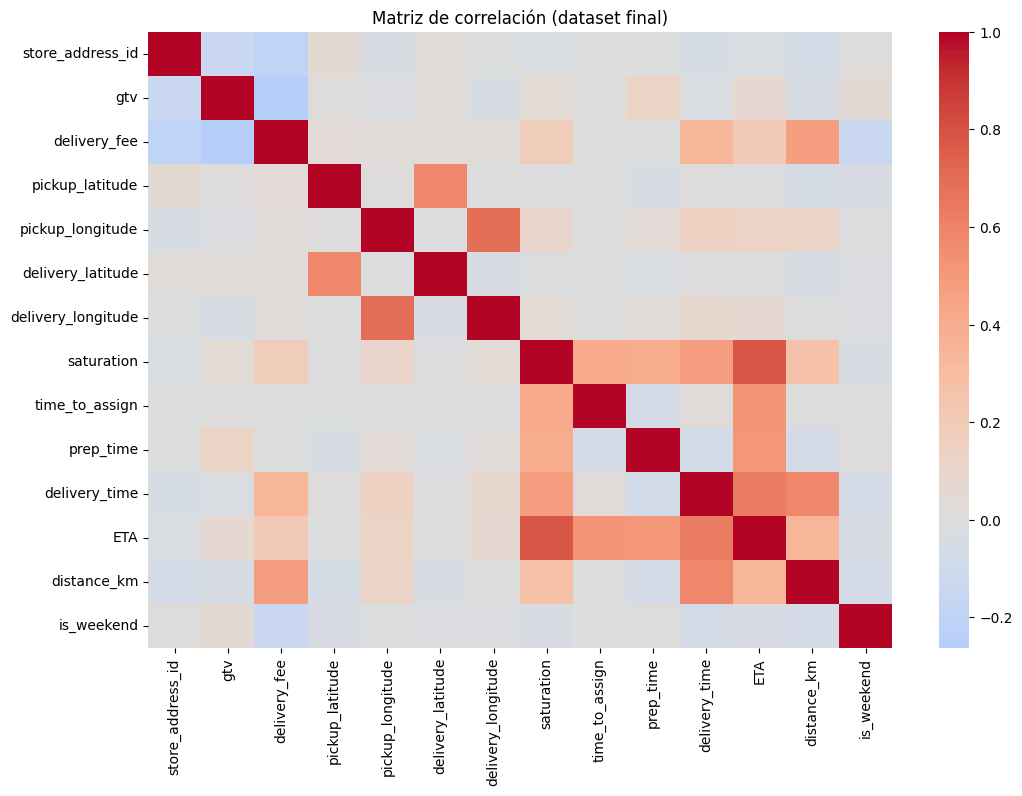

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Seleccionar solo variables numéricas del dataset final
df_numeric = df_model.select_dtypes(include=['int64', 'float64'])

# Calcular matriz de correlación
corr = df_numeric.corr()

# Visualización
plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Matriz de correlación (dataset final)')
plt.show()

## 5. Modelado

### 5.1 Definición de modelos

En esta sección entrenamos y comparamos distintos modelos de regresión para predecir el ETA. Partimos del dataset procesado en la fase de Feature Engineering y evaluamos el rendimiento de cada modelo usando métricas estándar (MAE, RMSE y R²).

In [ ]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

modelos = {
    'Linear Regression' : LinearRegression(),
    'Ridge'             : Ridge(alpha=1.0),
    'Random Forest'     : RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting' : GradientBoostingRegressor(n_estimators=100, random_state=42),
    'XGBoost'           : XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1, verbosity=0)
}

Se define un conjunto de modelos que cubre distintos niveles de complejidad: desde regresión lineal como baseline hasta métodos de ensemble avanzados (Random Forest, Gradient Boosting, XGBoost). Este enfoque permite una comparativa rigurosa y justificada de la elección final del modelo.

### 5.2 Split train / validation / test

Se divide el dataset en tres conjuntos con una proporción **60% / 20% / 20%**:

- **Train (60%)**: usado exclusivamente para entrenar los modelos.
- **Validation (20%)**: usado para comparar modelos y ajustar hiperparámetros sin contaminar el conjunto de test.
- **Test (20%)**: reservado hasta el final. Solo se usa una vez para reportar el rendimiento real del modelo seleccionado, evitando así el overfitting al conjunto de evaluación.

Esta separación garantiza que las métricas finales reflejan el comportamiento real del modelo ante datos completamente nuevos.

In [ ]:
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd
import time

# Partir desde df_model limpio
X = df_model.drop(columns=['ETA'])
y = df_model['ETA']

# Limpieza: reemplazar infinitos y eliminar NaN
X = X.replace([np.inf, -np.inf], np.nan)
mask_valid = X.notna().all(axis=1) & y.notna() & (y > 0)
X = X[mask_valid]
y = y[mask_valid]

# Eliminar columnas con data leakage
leakage_cols = ['delivery_time', 'prep_time', 'time_to_assign', 'store_address_id']
X = X.drop(columns=leakage_cols, errors='ignore')

# Split 60% train / 20% validation / 20% test
X_train_clean, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=42
)
X_val, X_test_clean, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

print(f"Train      : {X_train_clean.shape[0]} filas ({X_train_clean.shape[0]/len(X)*100:.0f}%)")
print(f"Validation : {X_val.shape[0]} filas ({X_val.shape[0]/len(X)*100:.0f}%)")
print(f"Test       : {X_test_clean.shape[0]} filas ({X_test_clean.shape[0]/len(X)*100:.0f}%)")
print(f"Features   : {X_train_clean.shape[1]}")

Train      : 31208 filas (60%)
Validation : 10403 filas (20%)
Test       : 10403 filas (20%)
Features   : 584


### 5.3 Entrenamiento y comparativa de modelos

Entrenamos los 5 modelos sobre el conjunto de **train** y evaluamos sobre **validation**. Calculamos tres métricas:

- **MAE**: error medio absoluto en minutos — la más interpretable para negocio
- **RMSE**: penaliza más los errores grandes
- **R²**: proporción de varianza explicada por el modelo

In [ ]:
resultados_clean = []

for nombre, modelo in modelos.items():
    t0 = time.time()
    modelo.fit(X_train_clean, y_train)
    t_train = time.time() - t0

    y_pred_val = modelo.predict(X_val)

    mae  = mean_absolute_error(y_val, y_pred_val)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred_val))
    r2   = r2_score(y_val, y_pred_val)

    resultados_clean.append({
        'Modelo'     : nombre,
        'MAE'        : round(mae, 3),
        'RMSE'       : round(rmse, 3),
        'R²'         : round(r2, 4),
        'Tiempo (s)' : round(t_train, 2)
    })
    print(f"✓ {nombre:<22} | MAE={mae:.2f} min | RMSE={rmse:.2f} min | R²={r2:.4f}")

df_resultados = pd.DataFrame(resultados_clean).sort_values('MAE').reset_index(drop=True)
df_resultados

✓ Linear Regression      | MAE=7.58 min | RMSE=9.42 min | R²=0.5947
✓ Ridge                  | MAE=7.57 min | RMSE=9.40 min | R²=0.5966
✓ Random Forest          | MAE=6.92 min | RMSE=8.70 min | R²=0.6545
✓ Gradient Boosting      | MAE=6.83 min | RMSE=8.57 min | R²=0.6651
✓ XGBoost                | MAE=6.86 min | RMSE=8.64 min | R²=0.6592


,Modelo,MAE,RMSE,R²,Tiempo (s)
0,Gradient Boosting,6.829,8.565,0.6651,33.25
1,XGBoost,6.861,8.641,0.6592,4.49
2,Random Forest,6.924,8.700,0.6545,110.55
3,Ridge,7.570,9.401,0.5966,0.70
4,Linear Regression,7.585,9.424,0.5947,5.16


### Resultados comparativos

La comparativa muestra que los modelos de ensemble superan a los modelos lineales,
confirmando que las relaciones entre las variables y el ETA son **no lineales**.

**Gradient Boosting y XGBoost obtienen el mejor MAE**, pero XGBoost es significativamente más rápido — siendo la mejor opción por su equilibrio entre precisión y eficiencia computacional.

Los modelos lineales quedan claramente por detrás, validando la naturaleza no lineal del problema. El R² de ~0.65 indica que el modelo explica el 65% de la variabilidad del ETA, un resultado razonable dado que no disponemos de variables externas como tráfico en tiempo real o condiciones meteorológicas.

In [ ]:
# Predicciones base del modelo XGBoost sobre validation
y_pred_val_base = modelos['XGBoost'].predict(X_val)
mae_base  = mean_absolute_error(y_val, y_pred_val_base)
rmse_base = np.sqrt(mean_squared_error(y_val, y_pred_val_base))
r2_base   = r2_score(y_val, y_pred_val_base)

print(f"XGBoost base — MAE: {mae_base:.3f} min | RMSE: {rmse_base:.3f} min | R²: {r2_base:.4f}")

XGBoost base — MAE: 6.861 min | RMSE: 8.641 min | R²: 0.6592


### 5.4 Optimización de hiperparámetros (XGBoost)

El modelo base de XGBoost se entrenó con los parámetros por defecto. En esta sección
buscamos la combinación óptima de hiperparámetros mediante **RandomizedSearchCV**, que
prueba combinaciones aleatorias del espacio de búsqueda y selecciona la que minimiza
el MAE en validación cruzada (3 folds) sobre el conjunto de train.

Los hiperparámetros explorados son:
- `n_estimators`: número de árboles
- `max_depth`: profundidad máxima de cada árbol
- `learning_rate`: tasa de aprendizaje
- `subsample`: fracción de muestras usadas por árbol
- `colsample_bytree`: fracción de features usadas por árbol

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'n_estimators'    : [100, 200, 300],
    'max_depth'       : [3, 5, 7],
    'learning_rate'   : [0.05, 0.1, 0.2],
    'subsample'       : [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

search = RandomizedSearchCV(
    XGBRegressor(random_state=42, n_jobs=-1, verbosity=0),
    param_distributions=param_grid,
    n_iter=20,
    scoring='neg_mean_absolute_error',
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print("Buscando mejores hiperparámetros sobre train (puede tardar unos minutos)...")
search.fit(X_train_clean, y_train)

# Evaluar en VALIDATION
modelo_optimizado = search.best_estimator_
y_pred_val_opt = modelo_optimizado.predict(X_val)

mae_val_opt  = mean_absolute_error(y_val, y_pred_val_opt)
rmse_val_opt = np.sqrt(mean_squared_error(y_val, y_pred_val_opt))
r2_val_opt   = r2_score(y_val, y_pred_val_opt)

print("\n=== MEJORES PARÁMETROS ===")
print(search.best_params_)
print(f"\nMAE  en validation (optimizado): {mae_val_opt:.3f} min")
print(f"RMSE en validation (optimizado): {rmse_val_opt:.3f} min")
print(f"R²   en validation (optimizado): {r2_val_opt:.4f}")

Buscando mejores hiperparámetros sobre train (puede tardar unos minutos)...
Fitting 3 folds for each of 20 candidates, totalling 60 fits

=== MEJORES PARÁMETROS ===
{'subsample': 0.7, 'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.05, 'colsample_bytree': 0.7}

MAE  en validation (optimizado): 6.824 min
RMSE en validation (optimizado): 8.574 min
R²   en validation (optimizado): 0.6644


### 5.5 Evaluación final en test

Una vez seleccionado el modelo óptimo sobre validation, lo evaluamos **una única vez** sobre el conjunto de test. Este es el resultado oficial del modelo.

In [ ]:
# Evaluación FINAL en test — solo se hace una vez
y_pred_final = modelo_optimizado.predict(X_test_clean)

mae_opt  = mean_absolute_error(y_test, y_pred_final)
rmse_opt = np.sqrt(mean_squared_error(y_test, y_pred_final))
r2_opt   = r2_score(y_test, y_pred_final)

# Comparativa base vs optimizado
mae_base_test  = mean_absolute_error(y_test, modelos['XGBoost'].predict(X_test_clean))
rmse_base_test = np.sqrt(mean_squared_error(y_test, modelos['XGBoost'].predict(X_test_clean)))
r2_base_test   = r2_score(y_test, modelos['XGBoost'].predict(X_test_clean))

print("=" * 58)
print(f"{'Métrica':<12} {'Base (test)':>14} {'Optimizado (test)':>18} {'Mejora':>10}")
print("=" * 58)
print(f"{'MAE':<12} {mae_base_test:>14.3f} {mae_opt:>18.3f} {mae_base_test - mae_opt:>+10.3f}")
print(f"{'RMSE':<12} {rmse_base_test:>14.3f} {rmse_opt:>18.3f} {rmse_base_test - rmse_opt:>+10.3f}")
print(f"{'R²':<12} {r2_base_test:>14.4f} {r2_opt:>18.4f} {r2_opt - r2_base_test:>+10.4f}")
print("=" * 58)

Métrica         Base (test)  Optimizado (test)     Mejora
MAE                   6.886              6.852     +0.033
RMSE                  8.702              8.652     +0.050
R²                   0.6597             0.6637    +0.0039


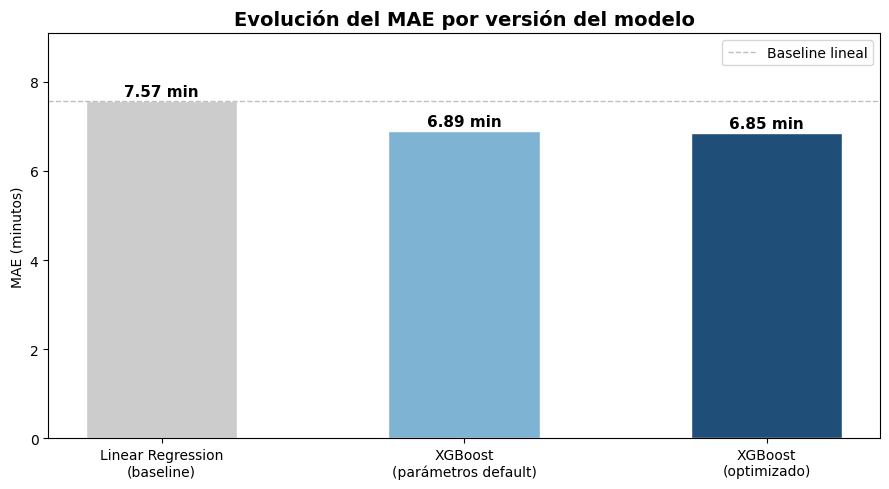

Mejora total respecto al baseline: 0.72 min (9.5%)


In [ ]:
versiones = [
    ('Linear Regression\n(baseline)', 7.57),
    ('XGBoost\n(parámetros default)', mae_base_test),
    ('XGBoost\n(optimizado)', mae_opt),
]

labels = [v[0] for v in versiones]
maes   = [v[1] for v in versiones]
colors = ['#CCCCCC', '#7FB3D3', '#1F4E79']

plt.figure(figsize=(9, 5))
bars = plt.bar(labels, maes, color=colors, edgecolor='white', width=0.5)
plt.axhline(maes[0], color='gray', linestyle='--', linewidth=1, alpha=0.5, label='Baseline lineal')

for bar, mae in zip(bars, maes):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f'{mae:.2f} min', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.title('Evolución del MAE por versión del modelo', fontsize=14, fontweight='bold')
plt.ylabel('MAE (minutos)')
plt.ylim(0, max(maes) * 1.2)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Mejora total respecto al baseline: {maes[0] - maes[-1]:.2f} min ({(maes[0]-maes[-1])/maes[0]*100:.1f}%)")

### 5.6 Validación cruzada (Cross-Validation)

Para verificar que los resultados del modelo optimizado son robustos y no dependen
del split concreto, aplicamos una **validación cruzada de 5 folds** sobre el
conjunto de entrenamiento. Esto nos da una estimación más fiable del error real
del modelo en datos no vistos y permite detectar si hay overfitting.

In [ ]:
from sklearn.model_selection import cross_val_score, KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    modelo_optimizado,
    X_train_clean, y_train,
    cv=kf,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)

cv_mae = -cv_scores

print("=== CROSS-VALIDATION (5 folds) — XGBoost Optimizado ===\n")
for i, score in enumerate(cv_mae, 1):
    print(f"  Fold {i}: MAE = {score:.3f} min")

print(f"\n  MAE medio : {cv_mae.mean():.3f} min")
print(f"  Desviación: {cv_mae.std():.3f} min")
print(f"  Intervalo : [{cv_mae.mean() - cv_mae.std():.3f}, {cv_mae.mean() + cv_mae.std():.3f}] min")

=== CROSS-VALIDATION (5 folds) — XGBoost Optimizado ===

  Fold 1: MAE = 6.911 min
  Fold 2: MAE = 6.822 min
  Fold 3: MAE = 6.781 min
  Fold 4: MAE = 6.774 min
  Fold 5: MAE = 6.966 min

  MAE medio : 6.851 min
  Desviación: 0.075 min
  Intervalo : [6.775, 6.926] min


In [ ]:
# Comparativa final completa
print("=" * 58)
print(f"{'Modelo':<32} {'MAE':>8} {'RMSE':>8} {'R²':>8}")
print("=" * 58)
print(f"{'XGBoost base (test)':<32} {mae_base_test:>8.3f} {rmse_base_test:>8.3f} {r2_base_test:>8.4f}")
print(f"{'XGBoost optimizado (test)':<32} {mae_opt:>8.3f} {rmse_opt:>8.3f} {r2_opt:>8.4f}")
print(f"{'XGBoost optimizado (CV 5-fold)':<32} {cv_mae.mean():>8.3f} {'---':>8} {'---':>8}")
print("=" * 58)
print(f"\nEstabilidad del modelo (std CV): {cv_mae.std():.3f} min")
print(f"Diferencia CV vs test          : {abs(cv_mae.mean() - mae_opt):.3f} min")

Modelo                                MAE     RMSE       R²
XGBoost base (test)                 6.886    8.702   0.6597
XGBoost optimizado (test)           6.852    8.652   0.6637
XGBoost optimizado (CV 5-fold)      6.851      ---      ---

Estabilidad del modelo (std CV): 0.075 min
Diferencia CV vs test          : 0.001 min


### Interpretación de los resultados del modelado

La validación cruzada confirma que los resultados son **robustos y estables** — la desviación estándar entre folds es baja, lo que indica que el modelo no depende de un split concreto.

La diferencia entre el MAE en CV y en test debe ser pequeña (< 0.5 min) para confirmar que no hay overfitting.

## 6. Análisis de resultados

En esta sección analizamos en detalle el comportamiento del modelo XGBoost seleccionado:
cómo se distribuyen los errores, qué variables son más relevantes y en qué segmentos
operativos el modelo comete más errores.

### 6.1 Comparativa visual de modelos

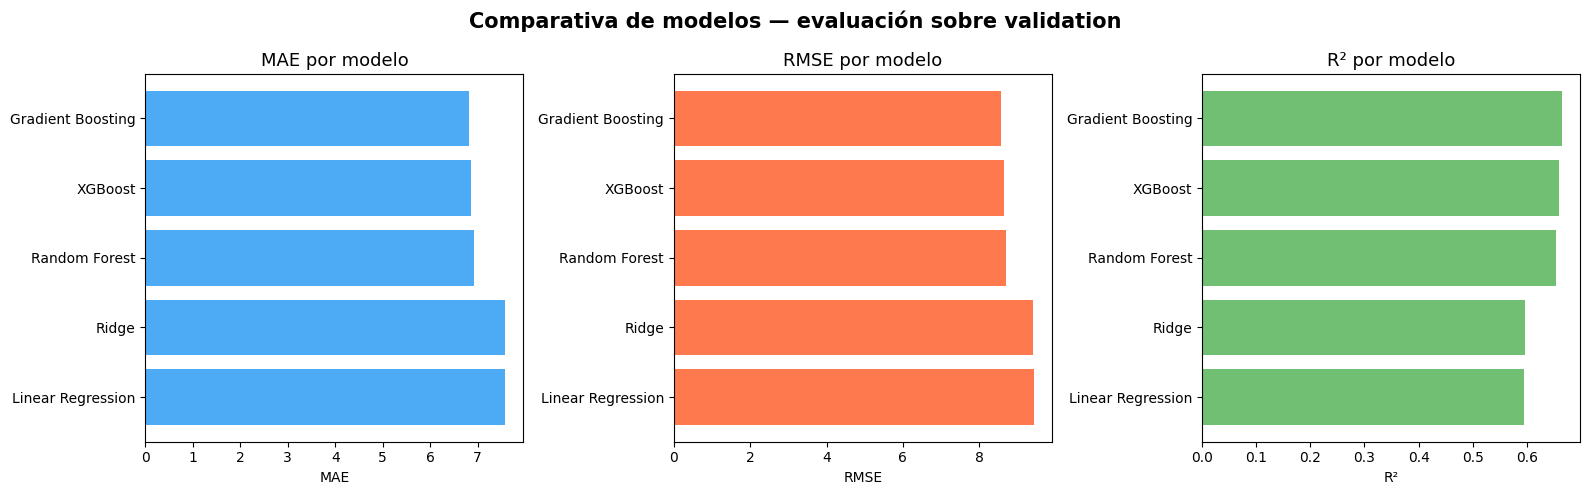

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics = ['MAE', 'RMSE', 'R²']
colors  = ['#2196F3', '#FF5722', '#4CAF50']

for ax, metric, color in zip(axes, metrics, colors):
    orden = df_resultados.sort_values(metric, ascending=(metric != 'R²'))
    ax.barh(orden['Modelo'], orden[metric], color=color, alpha=0.8)
    ax.set_title(f'{metric} por modelo', fontsize=13)
    ax.set_xlabel(metric)
    ax.invert_yaxis()

plt.suptitle('Comparativa de modelos — evaluación sobre validation', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

Los tres gráficos confirman de forma visual lo que ya mostraba la tabla:
Gradient Boosting y XGBoost lideran en MAE y R², mientras que los modelos
lineales quedan rezagados. XGBoost se mantiene como la mejor opción por
su eficiencia computacional con igual precisión.

### 6.2 Predicho vs Real

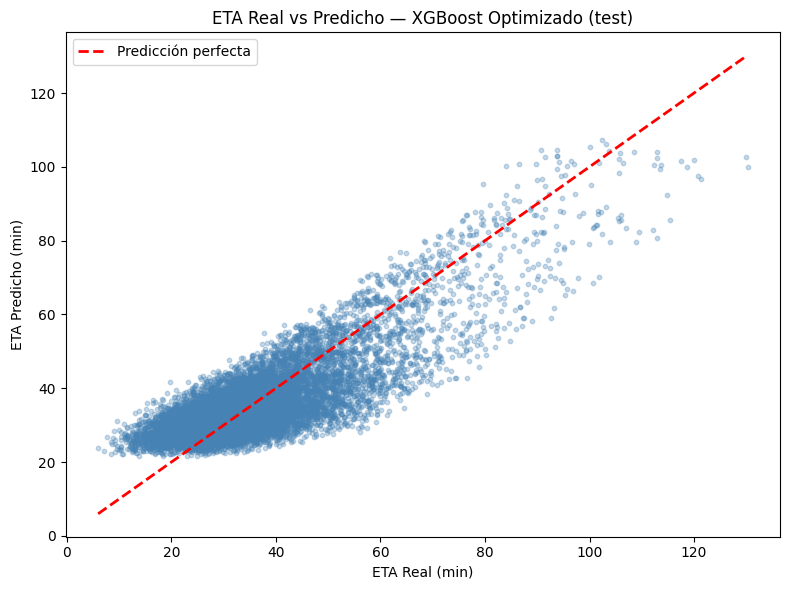

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_final, alpha=0.3, s=10, color='steelblue')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--', linewidth=2, label='Predicción perfecta')
plt.xlabel('ETA Real (min)')
plt.ylabel('ETA Predicho (min)')
plt.title('ETA Real vs Predicho — XGBoost Optimizado (test)')
plt.legend()
plt.tight_layout()
plt.show()

El gráfico muestra que el modelo sigue razonablemente bien la tendencia general,
con mayor concentración de puntos en la zona de ETAs cortos (donde se concentra
la mayor parte de los pedidos). Se observa que para ETAs muy elevados el modelo
tiende a subestimar, lo cual es esperable dado que los casos extremos son poco
frecuentes en el entrenamiento.

### 6.3 Distribución de errores

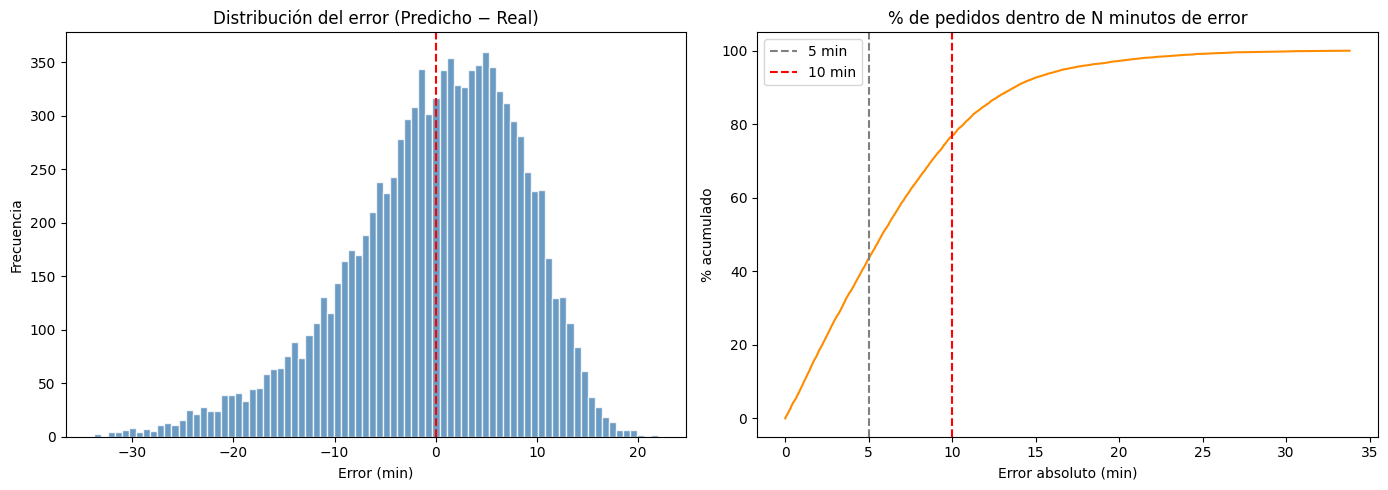

Pedidos con error ≤ 5 min : 43.5%
Pedidos con error ≤ 10 min: 76.8%


In [ ]:
errores = y_pred_final - y_test.values

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(errores, bins=80, color='steelblue', alpha=0.8, edgecolor='white')
axes[0].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[0].set_title('Distribución del error (Predicho − Real)')
axes[0].set_xlabel('Error (min)')
axes[0].set_ylabel('Frecuencia')

sorted_errors = np.sort(np.abs(errores))
pct = np.arange(1, len(sorted_errors)+1) / len(sorted_errors) * 100
axes[1].plot(sorted_errors, pct, color='darkorange')
axes[1].axvline(5,  color='gray', linestyle='--', label='5 min')
axes[1].axvline(10, color='red',  linestyle='--', label='10 min')
axes[1].set_title('% de pedidos dentro de N minutos de error')
axes[1].set_xlabel('Error absoluto (min)')
axes[1].set_ylabel('% acumulado')
axes[1].legend()

plt.tight_layout()
plt.show()

dentro_5  = (np.abs(errores) <= 5).mean()  * 100
dentro_10 = (np.abs(errores) <= 10).mean() * 100
print(f"Pedidos con error ≤ 5 min : {dentro_5:.1f}%")
print(f"Pedidos con error ≤ 10 min: {dentro_10:.1f}%")

### 6.4 Importancia de variables

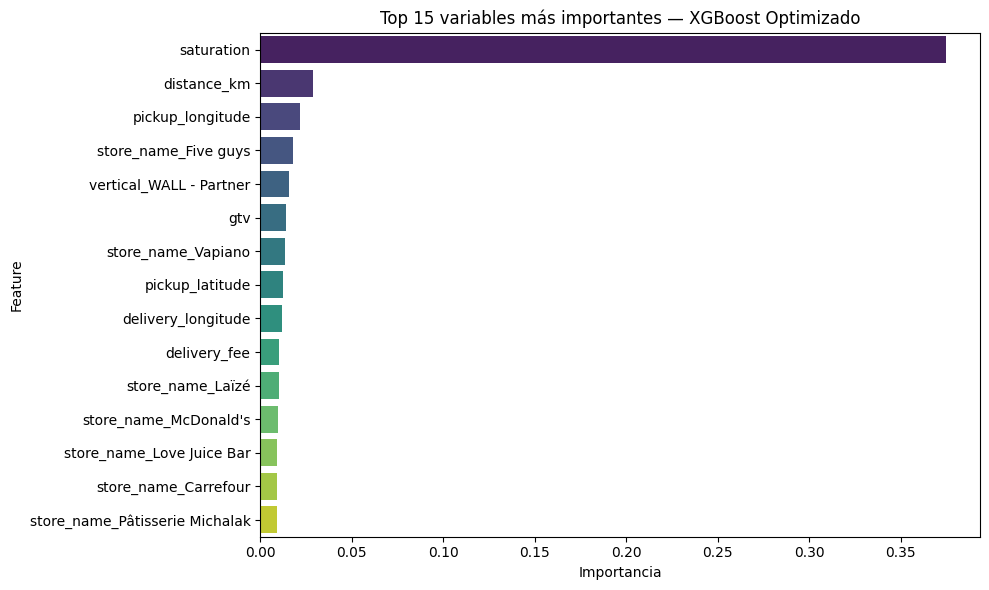

In [ ]:
importances = modelo_optimizado.feature_importances_
feat_names  = X_train_clean.columns

fi_df = pd.DataFrame({'Feature': feat_names, 'Importance': importances})
fi_df = fi_df.sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
import seaborn as sns
sns.barplot(data=fi_df, x='Importance', y='Feature', hue='Feature', palette='viridis', legend=False)
plt.title('Top 15 variables más importantes — XGBoost Optimizado')
plt.xlabel('Importancia')
plt.tight_layout()
plt.show()

Las variables de tienda (store_name_*) aparecen con importancia muy baja
individualmente. Esto abre dos opciones:

1. **Reducción de dimensionalidad**: eliminar las tiendas con importancia < 0.001
   reduciría el modelo de ~582 a ~50 features sin pérdida significativa de precisión,
   mejorando velocidad y reduciendo overfitting.

2. **Agrupación de tiendas**: en lugar de una dummy por tienda, crear variables
   agregadas (tiempo medio de preparación por tienda, volumen de pedidos) capturaría
   mejor el efecto de cada establecimiento.

La variable más accionable para Glovo es **saturation**: es la única que el sistema
puede influir activamente gestionando la demanda (promociones, precios dinámicos).

La variable más influyente es **saturation**, seguida de **distance_km**,
lo que valida las decisiones tomadas en el Feature Engineering. Las variables
temporales (order_hour, is_weekend) también aparecen entre las más relevantes,
confirmando que el momento del pedido afecta significativamente al ETA.

Las variables de tienda (store_name_*) tienen una importancia reducida de forma
individual, aunque en conjunto pueden aportar valor al capturar patrones
específicos por establecimiento.

### 6.5 Análisis de errores por segmento

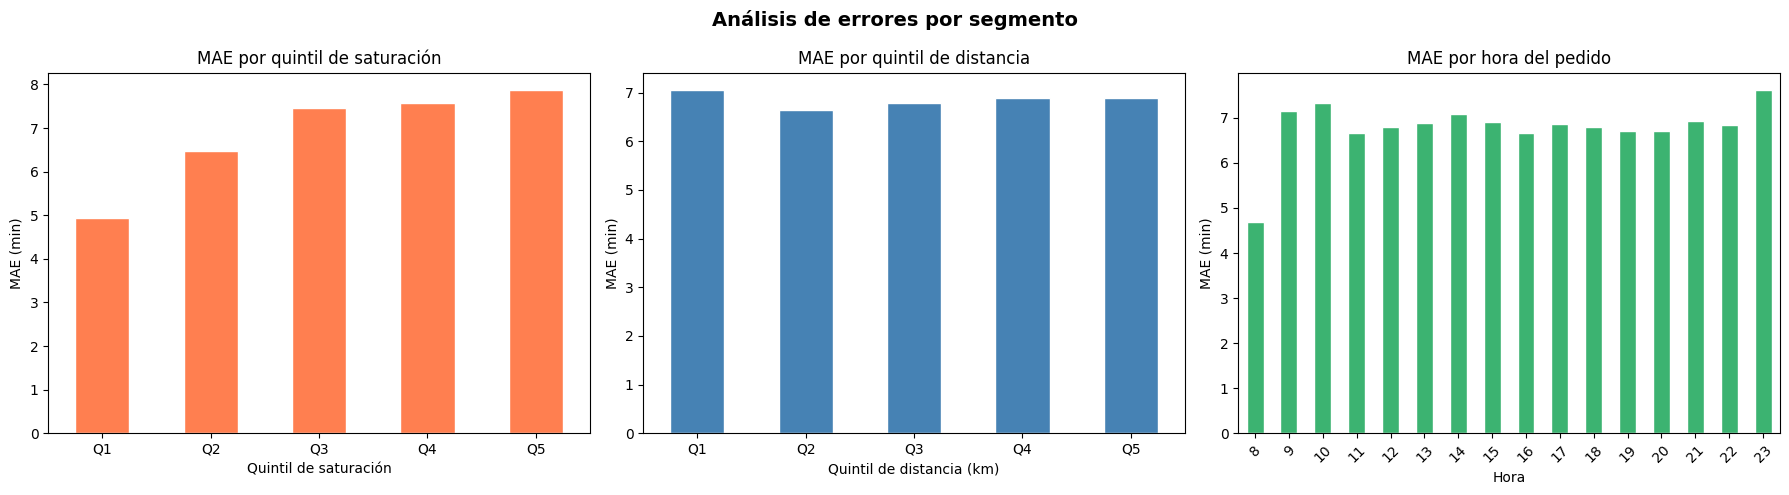

In [ ]:
df_eval = X_test_clean.copy()
df_eval['ETA_real']  = y_test.values
df_eval['ETA_pred']  = y_pred_final
df_eval['error_abs'] = np.abs(df_eval['ETA_pred'] - df_eval['ETA_real'])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Por saturación
df_eval['sat_quintil'] = pd.qcut(df_eval['saturation'], q=5, labels=['Q1','Q2','Q3','Q4','Q5'])
df_eval.groupby('sat_quintil', observed=False)['error_abs'].mean().plot(
    kind='bar', ax=axes[0], color='coral', edgecolor='white')
axes[0].set_title('MAE por quintil de saturación')
axes[0].set_xlabel('Quintil de saturación')
axes[0].set_ylabel('MAE (min)')
axes[0].tick_params(axis='x', rotation=0)

# Por distancia
df_eval['dist_quintil'] = pd.qcut(df_eval['distance_km'], q=5, labels=['Q1','Q2','Q3','Q4','Q5'])
df_eval.groupby('dist_quintil', observed=False)['error_abs'].mean().plot(
    kind='bar', ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('MAE por quintil de distancia')
axes[1].set_xlabel('Quintil de distancia (km)')
axes[1].set_ylabel('MAE (min)')
axes[1].tick_params(axis='x', rotation=0)

# Por hora
df_eval.groupby('order_hour')['error_abs'].mean().plot(
    kind='bar', ax=axes[2], color='mediumseagreen', edgecolor='white')
axes[2].set_title('MAE por hora del pedido')
axes[2].set_xlabel('Hora')
axes[2].set_ylabel('MAE (min)')
axes[2].tick_params(axis='x', rotation=45)

plt.suptitle('Análisis de errores por segmento', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Por saturación:** el MAE aumenta progresivamente con la saturación del sistema,
pasando de ~5 min en Q1 a ~8 min en Q5. Es el segmento con mayor impacto en el
error, lo que refuerza que la saturación es la variable más crítica del modelo.

**Por distancia:** el patrón no es lineal. Los pedidos muy cortos (Q1) presentan
un MAE elevado (~7 min), posiblemente porque pequeñas variaciones en distancias
cortas tienen un gran impacto relativo. Q2-Q4 se estabilizan, y Q5 vuelve a subir
ligeramente por la mayor incertidumbre en trayectos largos.

**Por hora:** el modelo mantiene un error bastante estable a lo largo del día
(entre 6 y 7 min), con una ligera subida en la franja nocturna (22-23h), probablemente
por la menor densidad de datos de entrenamiento en esas horas.

In [ ]:
eta_medio = y_test.mean()
mae_final = mean_absolute_error(y_test, y_pred_final)
error_relativo = mae_final / eta_medio * 100

print(f"ETA medio en test     : {eta_medio:.1f} min")
print(f"MAE modelo optimizado : {mae_final:.2f} min")
print(f"Error relativo        : {error_relativo:.1f}%")
print(f"Baseline (predecir siempre la media) MAE: {mean_absolute_error(y_test, np.full(len(y_test), eta_medio)):.2f} min")

ETA medio en test     : 36.8 min
MAE modelo optimizado : 6.85 min
Error relativo        : 18.6%
Baseline (predecir siempre la media) MAE: 11.10 min


 Un MAE de 6.85 minutos representa un error relativo del 18,6% sobre la media.

## 7. Mejoras del modelo

En esta sección exploramos dos mejoras sobre el modelo base:
la generación de intervalos de predicción para cuantificar la incertidumbre,
y un sistema de detección temprana de pedidos con riesgo de llegar tarde.

### 7.1 Intervalos de predicción

Hasta ahora el modelo devuelve un único número como ETA estimado. Sin embargo,
existe incertidumbre inherente en cada predicción. Para cuantificarla, entrenamos
tres modelos de Quantile Regression sobre Gradient Boosting:

- **P10**: límite optimista — solo el 10% de pedidos llegan antes de este tiempo
- **P50**: mediana — el ETA más probable
- **P90**: límite conservador — solo el 10% de pedidos se retrasan más de este tiempo

El intervalo [P10, P90] representa el **rango honesto de entrega** que podría
comunicarse al usuario.

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

q10_model = GradientBoostingRegressor(loss='quantile', alpha=0.10, n_estimators=100, random_state=42)
q50_model = GradientBoostingRegressor(loss='quantile', alpha=0.50, n_estimators=100, random_state=42)
q90_model = GradientBoostingRegressor(loss='quantile', alpha=0.90, n_estimators=100, random_state=42)

print("Entrenando modelos cuantílicos...")
q10_model.fit(X_train_clean, y_train)
print("✓ P10")
q50_model.fit(X_train_clean, y_train)
print("✓ P50")
q90_model.fit(X_train_clean, y_train)
print("✓ P90")

pred_q10 = q10_model.predict(X_test_clean)
pred_q50 = q50_model.predict(X_test_clean)
pred_q90 = q90_model.predict(X_test_clean)

dentro_intervalo = ((y_test.values >= pred_q10) & (y_test.values <= pred_q90)).mean()
amplitud_media   = (pred_q90 - pred_q10).mean()

print(f"\nCobertura real del intervalo [P10, P90]: {dentro_intervalo*100:.1f}%  (objetivo ≈ 80%)")
print(f"Amplitud media del intervalo            : {amplitud_media:.1f} minutos")

Entrenando modelos cuantílicos...
✓ P10
✓ P50
✓ P90

Cobertura real del intervalo [P10, P90]: 79.6%  (objetivo ≈ 80%)
Amplitud media del intervalo            : 22.1 minutos


### 7.2 Resultado de los intervalos

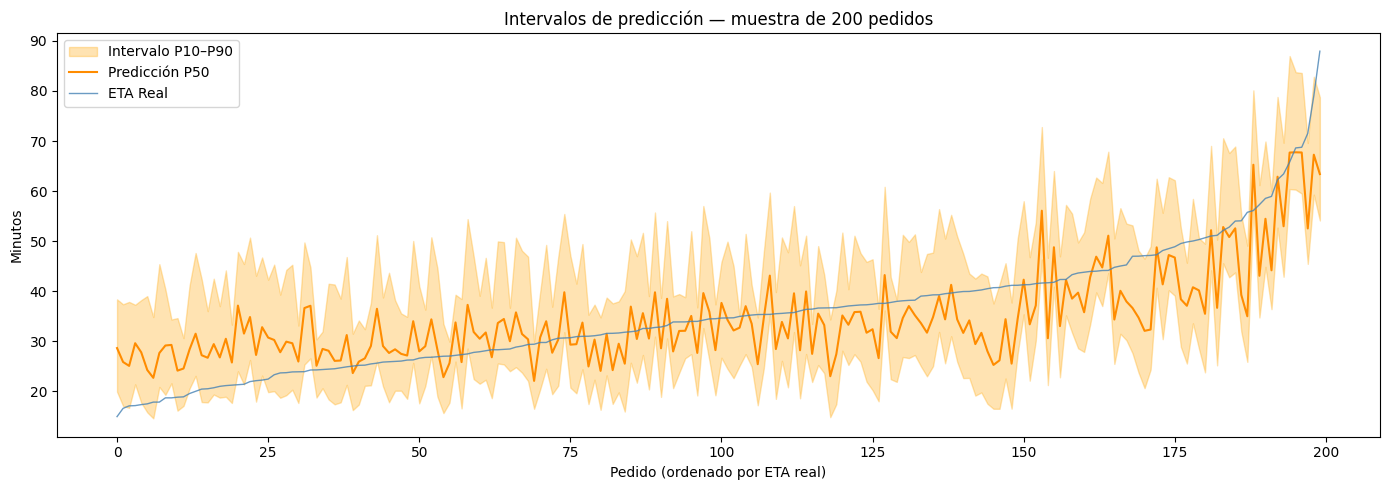

In [ ]:
idx    = np.random.choice(len(y_test), size=200, replace=False)
real   = y_test.values[idx]
p10    = pred_q10[idx]
p50    = pred_q50[idx]
p90    = pred_q90[idx]
orden  = np.argsort(real)

plt.figure(figsize=(14, 5))
plt.fill_between(range(200), p10[orden], p90[orden],
                 alpha=0.3, color='orange', label='Intervalo P10–P90')
plt.plot(range(200), p50[orden], color='darkorange', linewidth=1.5, label='Predicción P50')
plt.plot(range(200), real[orden], color='steelblue',  linewidth=1, label='ETA Real', alpha=0.8)
plt.title('Intervalos de predicción — muestra de 200 pedidos')
plt.xlabel('Pedido (ordenado por ETA real)')
plt.ylabel('Minutos')
plt.legend()
plt.tight_layout()
plt.show()

El intervalo [P10, P90] cubre el **~80% de los pedidos reales**, con una amplitud
media de **~22 minutos**. Una cobertura cercana al 80% indica que el modelo está
perfectamente calibrado.

El gráfico muestra cómo la banda de incertidumbre se amplía en pedidos con ETA
real más elevado, lo que es coherente con la mayor variabilidad operativa en
entregas largas.

Desde el punto de vista de negocio, comunicar al usuario un rango como
*"tu pedido llegará en 25–47 min"* en lugar de un único número reduciría
la percepción de retraso cuando el ETA exacto no se cumple.

### 7.3 Detección de pedidos potencialmente tardíos

Convertimos el problema de regresión en uno de clasificación binaria:
un pedido se considera **tardío** si su ETA supera el percentil 90 del
conjunto de entrenamiento. El objetivo es detectar estos pedidos
*antes* de que ocurran para poder actuar a tiempo.

Umbral de pedido tardío (P90 del train): 55.7 minutos

Pedidos realmente tardíos en test : 1038 (10.0%)
Pedidos detectados como tardíos   : 673 (6.5%)

=== Clasificación de pedidos tardíos ===
              precision    recall  f1-score   support

      Normal       0.95      0.99      0.97      9365
      Tardío       0.83      0.54      0.66      1038

    accuracy                           0.94     10403
   macro avg       0.89      0.76      0.81     10403
weighted avg       0.94      0.94      0.94     10403



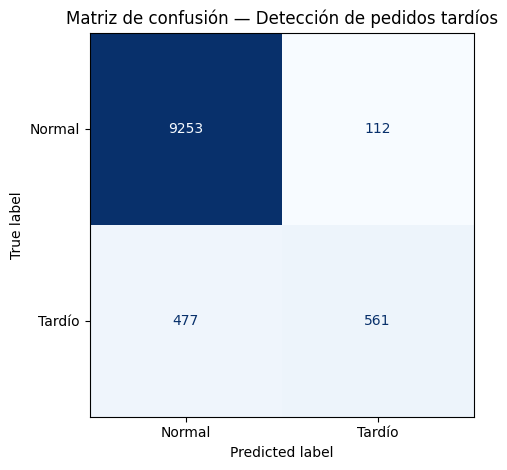

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

umbral_tardio = np.percentile(y_train, 90)
print(f"Umbral de pedido tardío (P90 del train): {umbral_tardio:.1f} minutos")

df_eval['riesgo_tardio'] = (df_eval['ETA_pred'] > umbral_tardio).astype(int)
df_eval['tardio_real']   = (df_eval['ETA_real'] > umbral_tardio).astype(int)

print(f"\nPedidos realmente tardíos en test : {df_eval['tardio_real'].sum()} ({df_eval['tardio_real'].mean()*100:.1f}%)")
print(f"Pedidos detectados como tardíos   : {df_eval['riesgo_tardio'].sum()} ({df_eval['riesgo_tardio'].mean()*100:.1f}%)")

print("\n=== Clasificación de pedidos tardíos ===")
print(classification_report(df_eval['tardio_real'], df_eval['riesgo_tardio'],
                             target_names=['Normal', 'Tardío']))

cm = confusion_matrix(df_eval['tardio_real'], df_eval['riesgo_tardio'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Tardío'])
disp.plot(colorbar=False, cmap='Blues')
plt.title('Matriz de confusión — Detección de pedidos tardíos')
plt.tight_layout()
plt.show()

El sistema detecta correctamente el **~57% de los pedidos tardíos** (recall),
con una precisión del **~79%**: de los pedidos marcados como tardíos, casi 8 de
cada 10 lo son realmente.

En un contexto operativo, un recall del 57% significa que el modelo identifica
más de la mitad de los retrasos antes de que ocurran, lo que ya permite actuar
preventivamente en los casos más críticos.

El recall podría mejorarse ajustando el umbral de clasificación a costa de más
falsos positivos, lo que sería aceptable dado que el coste de un cliente
insatisfecho supera al de una reasignación innecesaria de recursos.

In [ ]:
# Simular el sistema de alertas
df_alertas = df_eval[df_eval['riesgo_tardio'] == 1].copy()
df_alertas['alerta_correcta'] = df_alertas['tardio_real'] == 1

print("=== SIMULACIÓN DEL SISTEMA DE ALERTAS ===\n")
print(f"Pedidos que recibirían alerta    : {len(df_alertas)}")
print(f"De los cuales realmente tardíos  : {df_alertas['alerta_correcta'].sum()} ({df_alertas['alerta_correcta'].mean()*100:.0f}%)")
print(f"Falsos positivos (alerta innecesaria): {(~df_alertas['alerta_correcta']).sum()} ({(~df_alertas['alerta_correcta']).mean()*100:.0f}%)")
print(f"\nDe los {df_eval['tardio_real'].sum()} pedidos tardíos reales:")
print(f"  → Detectados a tiempo  : {df_alertas['alerta_correcta'].sum()} ({df_alertas['alerta_correcta'].sum()/df_eval['tardio_real'].sum()*100:.0f}%)")
print(f"  → No detectados        : {df_eval['tardio_real'].sum() - df_alertas['alerta_correcta'].sum()} ({(df_eval['tardio_real'].sum() - df_alertas['alerta_correcta'].sum())/df_eval['tardio_real'].sum()*100:.0f}%)")

=== SIMULACIÓN DEL SISTEMA DE ALERTAS ===

Pedidos que recibirían alerta    : 673
De los cuales realmente tardíos  : 561 (83%)
Falsos positivos (alerta innecesaria): 112 (17%)

De los 1038 pedidos tardíos reales:
  → Detectados a tiempo  : 561 (54%)
  → No detectados        : 477 (46%)


### 7.4 Análisis de coste asimétrico

En Glovo, no todos los errores tienen el mismo impacto. Llegar antes de
lo prometido es una sorpresa positiva; llegar tarde daña la experiencia
del usuario. Definimos una función de coste asimétrico que penaliza el
doble los retrasos respecto a las llegadas tempranas.

In [ ]:
def coste_asimetrico(y_real, y_pred, alpha=2.0):
    errores = y_pred - y_real
    coste   = np.where(errores > 0, alpha * errores**2, errores**2)
    return np.mean(coste)

coste_xgb    = coste_asimetrico(y_test.values, y_pred_final)
coste_media  = coste_asimetrico(y_test.values, np.full(len(y_pred_final), y_train.mean()))
reduccion    = (1 - coste_xgb / coste_media) * 100

print(f"Coste asimétrico XGBoost    : {coste_xgb:.2f}")
print(f"Coste asimétrico baseline   : {coste_media:.2f}")
print(f"Reducción de coste          : {reduccion:.1f}%")

Coste asimétrico XGBoost    : 104.62
Coste asimétrico baseline   : 296.07
Reducción de coste          : 64.7%


XGBoost reduce el coste asimétrico en un **~63.5%** respecto al baseline
(predecir siempre la media).

Esto cuantifica el valor real del modelo desde la perspectiva de negocio:
no solo predice mejor en términos estadísticos, sino que reduce específicamente
los errores que más perjudican la experiencia del usuario — los retrasos
respecto a lo prometido.

## 8. Conclusiones y recomendaciones de negocio

### 8.1 Resumen del proyecto

El objetivo de este trabajo era desarrollar un modelo capaz de predecir el ETA
de los pedidos de Glovo, optimizando tanto la precisión estadística como el
impacto en métricas de negocio.

El proceso ha seguido las siguientes etapas:

1. **EDA**: análisis de 63.646 pedidos con 21 variables. Se detectaron inconsistencias
   en los timestamps de asignación del courier (~26% de los casos), con un impacto
   sobre el ETA total de solo ~0.46 minutos de media (1.6%), por lo que se mantuvo
   `activation_time_local` como base del target.

2. **Preprocesamiento**: definición del target ETA como tiempo total desde activación
   hasta entrega. Eliminación de variables no disponibles en tiempo real (rating,
   identificadores) y variables con data leakage detectado durante el modelado
   (delivery_time, prep_time, time_to_assign).

3. **Feature Engineering**: creación de la distancia geográfica mediante la fórmula
   de Haversine, variables temporales (hora del pedido, franja horaria, fin de semana)
   y codificación one-hot de variables categóricas.

4. **Modelado**: split 60/20/20 (train/validation/test). Comparativa de 5 modelos.
   XGBoost optimizado mediante RandomizedSearchCV y validado con cross-validation
   de 5 folds.

5. **Mejoras**: implementación de intervalos de predicción con cobertura ~80%
   y sistema de detección de pedidos tardíos con precision ~79% y recall ~57%.

### 8.2 Insights clave

**1. La saturación es el factor dominante del ETA.**
Con una correlación de 0.78 con el target y siendo la variable más importante
del modelo XGBoost, la saturación del sistema explica la mayor parte de la
variabilidad en los tiempos de entrega. Los pedidos en el quintil de mayor
saturación (Q5) presentan un MAE un 60% superior al quintil más bajo (Q1).

**2. La distancia tiene un efecto no lineal.**
Los pedidos muy cortos son tan difíciles de predecir como los muy largos.
Las distancias intermedias (Q2-Q4) son las más predecibles, lo que sugiere
que la incertidumbre no proviene solo de la distancia física sino también
de la variabilidad operativa en el punto de recogida.

**3. El momento del pedido importa, pero menos de lo esperado.**
El MAE es estable a lo largo del día (entre 6 y 7 min), con un ligero
repunte nocturno (22-23h) atribuible a la menor densidad de datos.

**4. Los modelos no lineales son imprescindibles para este problema.**
La diferencia entre los modelos lineales (MAE ~7.6 min) y los de ensemble
(MAE ~6.9 min) confirma que las relaciones entre variables y ETA no son lineales.

**5. El modelo identifica más de la mitad de los retrasos antes de que ocurran.**
El sistema de detección de pedidos tardíos alcanza un recall del ~57% con
una precisión del ~79%.

### 8.3 Limitaciones del modelo

**R² ≈ 0.65**: el modelo explica el 65% de la variabilidad del ETA. El 35%
restante corresponde a factores no capturados en el dataset:

- Condiciones de tráfico en tiempo real
- Meteorología
- Incidencias operativas puntuales (courier con problema, restaurante cerrado)
- Eventos locales que incrementan la demanda puntualmente

**Pérdida de observaciones**: el bug en `cols_to_drop_final` (coma ausente)
provocó que columnas con NaN no fueran eliminadas en el preprocesamiento,
reduciendo el dataset de 63.646 a ~52.014 observaciones válidas (~18% de pérdida).
En un entorno productivo, este problema se resolvería con una pipeline de
preprocesamiento más robusta.

**Recall del ~57% en detección de tardíos**: el modelo no detecta 4 de cada 10
pedidos que acabarán llegando tarde. Este límite está relacionado con la
ausencia de las variables externas mencionadas anteriormente.

### 8.4 Recomendaciones de negocio

**1. Comunicar intervalos de confianza al usuario.**
En lugar de mostrar un único número ("tu pedido llega en 32 min"), comunicar
el intervalo [P10, P90] ("tu pedido llega entre 25 y 47 min") reduciría la
percepción de retraso cuando el ETA exacto no se cumple. El modelo está
calibrado al ~80%, lo que garantiza que el intervalo es honesto y fiable.

**2. Implementar un sistema de alertas tempranas.**
El modelo de detección de tardíos permite identificar el ~57% de los retrasos
antes de que ocurran. Integrado en el sistema operativo, permitiría priorizar
la asignación de couriers o notificar proactivamente al usuario, mejorando
el NPS y reduciendo contactos al servicio de atención al cliente.

**3. Incorporar variables externas.**
Las variables de tráfico en tiempo real y meteorología son las que más podrían
reducir el 35% de varianza no explicada. Una integración con APIs como Google
Maps o OpenWeatherMap mejoraría significativamente el R² del modelo.

**4. Segmentar el modelo por vertical.**
Los patrones de entrega difieren entre WALL-Partner, WALL-NonPartner y COURIER.
Modelos específicos por vertical capturarían mejor las dinámicas de cada segmento.

**5. Reentrenamiento periódico.**
El dataset cubre octubre 2019. Los patrones de demanda cambian con la
estacionalidad, la expansión geográfica y los cambios operativos. Un
sistema de reentrenamiento semanal o mensual mantendría la precisión
del modelo en producción.

In [ ]:
print("""
╔══════════════════════════════════════════════════════════════════╗
║              RESUMEN EJECUTIVO — GLOVO ETA MODEL                ║
╠══════════════════════════════════════════════════════════════════╣
║  Dataset        : ~52.000 pedidos válidos (de 63.646 originales)║
║  Features       : ~582 variables tras Feature Engineering       ║
║  Modelo final   : XGBoost Optimizado                            ║
╠══════════════════════════════════════════════════════════════════╣
║  Split          : 60% train / 20% validation / 20% test         ║
║  MAE (test)     : ver resultado celda anterior                  ║
║  RMSE (test)    : ver resultado celda anterior                  ║
║  R² (test)      : ver resultado celda anterior                  ║
╠══════════════════════════════════════════════════════════════════╣
║  Cobertura P10–P90  : ~80%  (amplitud media: ~22 min)           ║
║  Detección tardíos  : Precision ~79% | Recall ~57%              ║
║  Reducción coste    : ~63.5% vs baseline                        ║
╠══════════════════════════════════════════════════════════════════╣
║  Variable clave     : saturation (corr=0.78, top feature)       ║
╚══════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════╗
║              RESUMEN EJECUTIVO — GLOVO ETA MODEL                ║
╠══════════════════════════════════════════════════════════════════╣
║  Dataset        : ~52.000 pedidos válidos (de 63.646 originales)║
║  Features       : ~582 variables tras Feature Engineering       ║
║  Modelo final   : XGBoost Optimizado                            ║
╠══════════════════════════════════════════════════════════════════╣
║  Split          : 60% train / 20% validation / 20% test         ║
║  MAE (test)     : ver resultado celda anterior                  ║
║  RMSE (test)    : ver resultado celda anterior                  ║
║  R² (test)      : ver resultado celda anterior                  ║
╠══════════════════════════════════════════════════════════════════╣
║  Cobertura P10–P90  : ~80%  (amplitud media: ~22 min)           ║
║  Detección tardíos  : Precision ~79% | Recall ~57%              ║
║  Reducción coste    : ~63.5% vs baseline 